## 5. Evaluation

Walk-forward comparison on the shared horizon-1-to-8 grid, against seasonal-naive and the
RBA's own published forecasts. Aligning each forecast origin to the RBA's actual published Statement on Monetary Policy figures is prepared in [Appendix §14 — RBA Forecast Error Benchmark Preparation](appendix_eda/14_rba_forecast_benchmark).

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

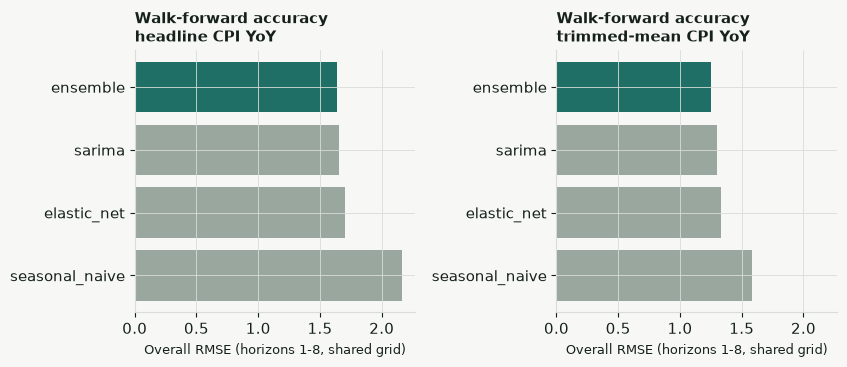

In [2]:
comp = pd.read_csv(PROJECT_ROOT / "reports/tableau/model_comparison.csv")
panels = [("Headline", "headline CPI YoY"), ("Trimmed mean", "trimmed-mean CPI YoY")]

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8), sharex=True)
for ax, (target, title) in zip(axes, panels):
    overall = comp[comp["target"] == target].sort_values("rmse")
    colors = [ACCENT if model == "ensemble" else "#9aa79f" for model in overall["model"]]
    ax.barh(overall["model"], overall["rmse"], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("Overall RMSE (horizons 1-8, shared grid)", fontsize=9)
    ax.set_title(f"Walk-forward accuracy\n{title}", loc="left", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

**Where the Ensemble's edge comes from.** The pooled RMSE above hides a crossover by horizon. SARIMA is the most accurate
family at horizons 1–3 on both targets (headline h1: 0.60 against the Ensemble's 0.70), while from horizon 5 onward
Elastic Net or the Ensemble is. Because squared errors are largest at long horizons, the pooled figure is driven by
those later horizons, which is where the Ensemble's small overall lead comes from.

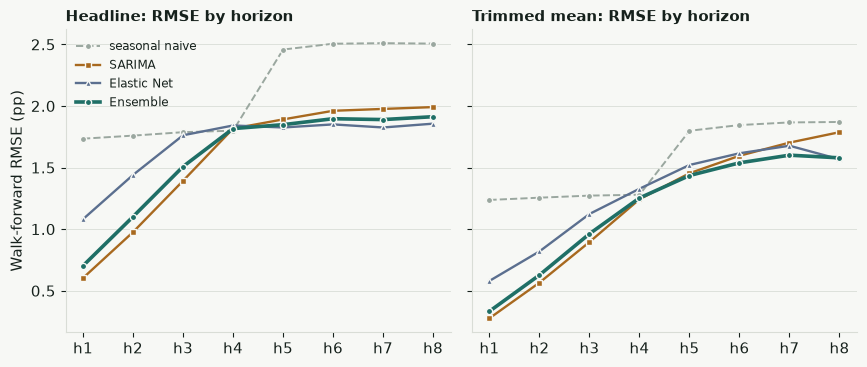

In [3]:
styles = {   # model: (label, colour, linestyle, linewidth, marker)
    "seasonal_naive": ("seasonal naive", MUTED, "--", 1.4, "o"),
    "sarima": ("SARIMA", HIGHLIGHT, "-", 1.7, "s"),
    "elastic_net": ("Elastic Net", BLUE, "-", 1.7, "^"),
    "ensemble": ("Ensemble", ACCENT, "-", 2.6, "o"),
}
sources = [("Headline", "reports/model_comparison_all.csv"),
           ("Trimmed mean", "reports/model_comparison_trimmed_mean_all.csv")]

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.8), sharey=True)
for ax, (title, rel) in zip(axes, sources):
    table = pd.read_csv(PROJECT_ROOT / rel)
    table = table[table["horizon"].astype(str) != "overall"].assign(horizon=lambda d: d["horizon"].astype(int))
    for model, (label, color, ls, lw, marker) in styles.items():
        sub = table[table["model"] == model].sort_values("horizon")
        ax.plot(sub["horizon"], sub["rmse"], color=color, linestyle=ls, linewidth=lw, marker=marker, markersize=4.5,
                markeredgecolor=PAPER, label=label)
    ax.set_title(f"{title}: RMSE by horizon", loc="left", fontsize=10.5, fontweight="bold")
    ax.set_xticks(range(1, 9), [f"h{h}" for h in range(1, 9)])
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Walk-forward RMSE (pp)")
axes[0].legend(frameon=False, fontsize=8.5, loc="upper left")
fig.tight_layout()
plt.show()

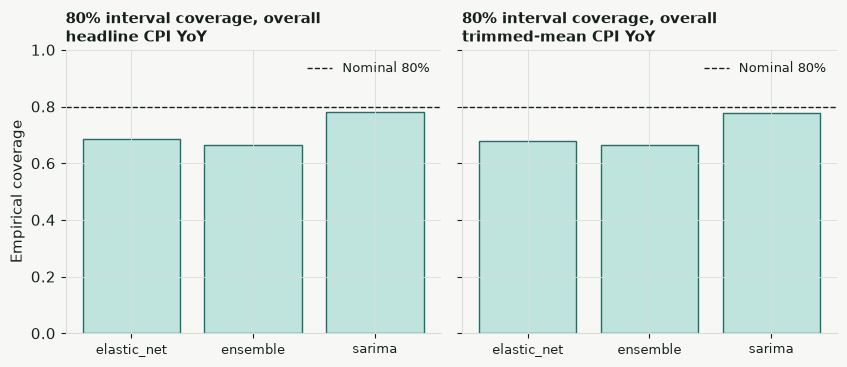

In [4]:
cov = pd.read_csv(PROJECT_ROOT / "reports/tableau/model_interval_coverage.csv")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8), sharey=True)
for ax, (target, title) in zip(axes, panels):
    cov_overall = cov[cov["target"] == target].sort_values("model")
    ax.axhline(cov_overall["nominal_coverage"].iloc[0], color=INK, linestyle="--",
               linewidth=1, label="Nominal 80%")
    ax.bar(cov_overall["model"], cov_overall["empirical_coverage"], color=ACCENT_SOFT, edgecolor=ACCENT)
    ax.set_ylim(0, 1)
    ax.set_title(f"80% interval coverage, overall\n{title}", loc="left", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", labelsize=9)
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("Empirical coverage")
fig.tight_layout()
plt.show()

Coverage looks different once the 2020–23 inflation surge is held out. Each marker below is the *calibrated* 80%
interval's coverage, first over all origins and then over the held-out 2020–23 origins only:

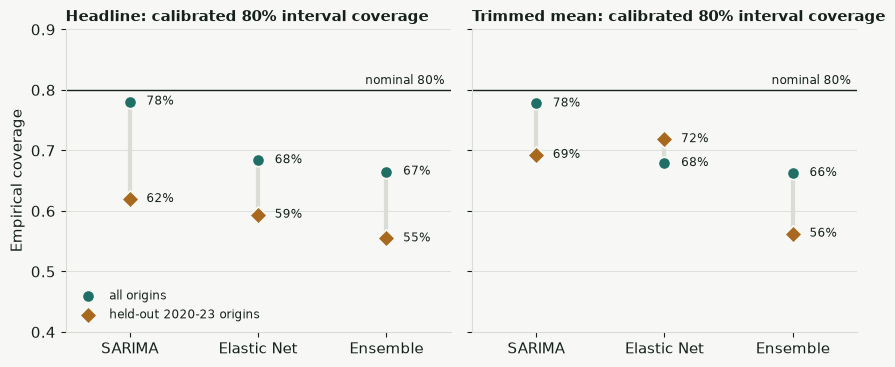

In [5]:
targets = [
    ("Headline", "reports/model_interval_coverage.csv", "reports/model_interval_calibration_validation.csv"),
    ("Trimmed mean", "reports/model_interval_coverage_trimmed_mean.csv", "reports/model_interval_calibration_validation_trimmed_mean.csv"),
]
families = [("sarima", "SARIMA"), ("elastic_net", "Elastic Net"), ("ensemble", "Ensemble")]

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.8), sharey=True)
for ax, (title, cov_rel, val_rel) in zip(axes, targets):
    cov = pd.read_csv(PROJECT_ROOT / cov_rel)
    val = pd.read_csv(PROJECT_ROOT / val_rel)
    cov = cov[cov["horizon"].astype(str) == "overall"].set_index("model")["empirical_coverage"]
    val = val[val["horizon"].astype(str) == "overall"].set_index("model")["calibrated_empirical_coverage"]
    ax.axhline(0.8, color=INK, linewidth=1.0)
    ax.text(2.45, 0.805, "nominal 80%", ha="right", va="bottom", fontsize=8.5)
    for x, (key, label) in enumerate(families):
        ax.plot([x, x], [val[key], cov[key]], color=GRID, linewidth=3, zorder=1)
        ax.scatter([x], [cov[key]], s=80, color=ACCENT, edgecolor=PAPER, linewidth=1.3, zorder=3,
                   label="all origins" if x == 0 else None)
        ax.scatter([x], [val[key]], s=80, marker="D", color=HIGHLIGHT, edgecolor=PAPER, linewidth=1.3, zorder=3,
                   label="held-out 2020-23 origins" if x == 0 else None)
        ax.annotate(f"{cov[key] * 100:.0f}%", (x, cov[key]), xytext=(12, 0), textcoords="offset points", va="center", fontsize=8.5)
        ax.annotate(f"{val[key] * 100:.0f}%", (x, val[key]), xytext=(12, 0), textcoords="offset points", va="center", fontsize=8.5)
    ax.set_xticks(range(3), [l for _, l in families])
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(0.4, 0.9)
    ax.set_title(f"{title}: calibrated 80% interval coverage", loc="left", fontsize=10.5, fontweight="bold")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Empirical coverage")
axes[0].legend(frameon=False, fontsize=8.5, loc="lower left")
fig.tight_layout()
plt.show()

Across both targets, Elastic Net and the Ensemble still fall short of their nominal 80% interval
coverage (`reports/tableau/model_interval_coverage.csv`); SARIMA now sits close to it and is no
longer flagged as significantly miscalibrated. SARIMA covers 78.1% for headline and 77.8% for
trimmed mean. Elastic Net covers 68.4% and 67.9%, respectively; the Ensemble covers 66.5% and 66.3%.

These intervals are calibrated with an ex-ante rolling scale factor: each forecast origin is widened
using only the forecast errors already observed by that quarter (pooled over the last 12 quarters),
scored on the side of the interval the outcome landed on. Coverage is much weaker on the 2020–23
origins, where errors jumped several-fold; there, held-out calibrated coverage is 56–72% for trimmed
mean and 55–62% for headline, at roughly twice the interval width. No interval built from past errors
can anticipate a shock of that size, so this narrows the gap without closing it. See
`reports/model_interval_calibration_remediation_decisions.md`.

The Ensemble has the lowest point-forecast RMSE on both targets: 1.640 for headline and
1.249 for trimmed mean, compared with SARIMA's 1.653 and 1.299. These modest point-forecast
gains do not resolve the interval-coverage gap. Seasonal naive is a point-forecast benchmark
and has no interval-coverage row in these exports.

#### Against the RBA's own published forecast (headline only)

The RBA's published CPI forecasts are for the non-seasonally-adjusted year-on-year rate, and the RBA publishes no
trimmed-mean forecast, so this comparison covers headline CPI only. Each forecaster is scored against its own actual: the
models against the seasonally adjusted actual they were trained on, the RBA against the non-seasonally-adjusted actual it was
forecasting. The two actuals differ by only 0.055pp on average (0.20pp at most), which is small next to forecast errors of
0.6–2.0pp. Everything is put on the models' exact forecast-origin, target-quarter and horizon grid (53 origins and horizons
1–8, 424 forecasts) with the same alignment used in [Appendix §14](appendix_eda/14_rba_forecast_benchmark).

424 forecasts, 53 origins; NSA vs SA actual differ by 0.055pp on average (max 0.20pp)
pooled RMSE: RBA 1.690 | SARIMA 1.653 | Elastic Net 1.706 | Ensemble 1.640
SARIMA minus RBA: -0.037, 95% paired-bootstrap interval [-0.121, +0.067]
Elastic Net minus RBA: +0.016, 95% paired-bootstrap interval [-0.118, +0.194]
Ensemble minus RBA: -0.049, 95% paired-bootstrap interval [-0.141, +0.061]


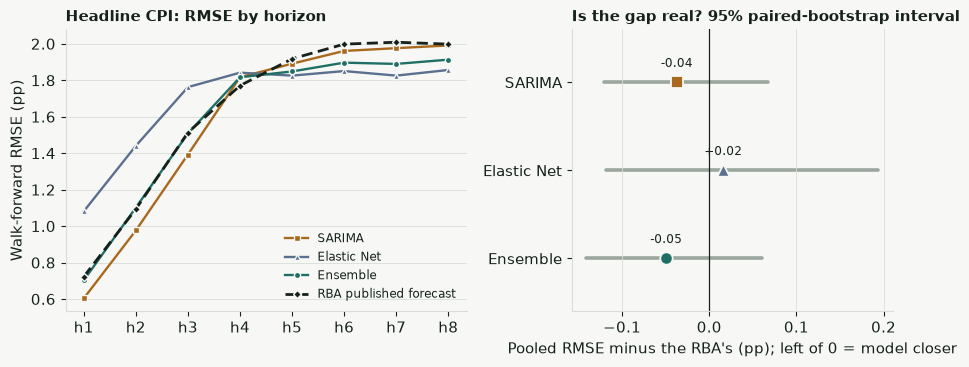

In [6]:
from src.models.evaluation import align_rba_forecasts_to_grid

backtest = pd.read_csv(PROJECT_ROOT / "reports/backtest_predictions.csv")
rba_raw = pd.read_csv(PROJECT_ROOT / "dataset/rba/rba_historical_cpi_forecasts_by_horizon_1995_2026.csv")

# the RBA's published forecasts, put on the models' exact origin / target-quarter / horizon grid
grid = backtest[backtest["model"] == "ensemble"][["forecast_origin", "target_quarter", "horizon", "actual"]]
rba = align_rba_forecasts_to_grid(rba_raw, grid)
KEY = ["forecast_origin", "target_quarter", "horizon"]
for frame in (rba,):
    for col in ("forecast_origin", "target_quarter"):
        frame[col] = frame[col].astype(str)
# the RBA is scored against its own (non-seasonally-adjusted) actual; the models against the SA actual
rba["rba_error"] = rba["rba_reported_error"]
basis_gap = (rba["rba_actual"] - rba["actual"]).abs()

families = [("sarima", "SARIMA", HIGHLIGHT, "s"), ("elastic_net", "Elastic Net", BLUE, "^"), ("ensemble", "Ensemble", ACCENT, "o")]
paired = {}
for key, *_ in families:
    m = backtest[backtest["model"] == key].merge(rba[KEY + ["rba_error"]], on=KEY)
    paired[key] = m
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))

# paired bootstrap over forecast origins: pooled RMSE of each family minus the RBA's, same resampled origins
rng = np.random.default_rng(42)
origins = paired["ensemble"]["forecast_origin"].unique()
cis = {}
for key, *_ in families:
    m = paired[key]
    g = m.groupby("forecast_origin").agg(sse=("error", lambda e: np.sum(np.square(e))), sse_r=("rba_error", lambda e: np.sum(np.square(e))),
                                         n=("error", "size")).loc[origins]
    idx = rng.integers(0, len(origins), size=(2000, len(origins)))
    n, sse, sse_r = g["n"].to_numpy()[idx].sum(1), g["sse"].to_numpy()[idx].sum(1), g["sse_r"].to_numpy()[idx].sum(1)
    diff = np.sqrt(sse / n) - np.sqrt(sse_r / n)
    cis[key] = (rmse(m["error"]) - rmse(m["rba_error"]), *np.percentile(diff, [2.5, 97.5]))
rba_pooled = rmse(paired["ensemble"]["rba_error"])
print(f"{len(rba)} forecasts, {len(origins)} origins; NSA vs SA actual differ by {basis_gap.mean():.3f}pp on average (max {basis_gap.max():.2f}pp)")
print(f"pooled RMSE: RBA {rba_pooled:.3f} | " + " | ".join(f"{lab} {rmse(paired[k]['error']):.3f}" for k, lab, *_ in families))
for key, lab, *_ in families:
    d, lo, hi = cis[key]
    print(f"{lab} minus RBA: {d:+.3f}, 95% paired-bootstrap interval [{lo:+.3f}, {hi:+.3f}]")

fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.8), gridspec_kw={"width_ratios": [1.25, 1]})
for key, lab, color, marker in families:
    by_h = paired[key].groupby("horizon")["error"].apply(rmse)
    a.plot(by_h.index, by_h.values, color=color, marker=marker, markersize=4.5, markeredgecolor=PAPER, linewidth=1.7, label=lab)
rba_h = paired["ensemble"].groupby("horizon")["rba_error"].apply(rmse)
a.plot(rba_h.index, rba_h.values, color=INK, linestyle=(0, (4, 2)), marker="D", markersize=4.5, markeredgecolor=PAPER,
       linewidth=2.0, label="RBA published forecast")
a.set_xticks(range(1, 9), [f"h{h}" for h in range(1, 9)])
a.set_ylabel("Walk-forward RMSE (pp)")
a.set_title("Headline CPI: RMSE by horizon", loc="left", fontsize=10.5, fontweight="bold")
a.legend(frameon=False, fontsize=8.3, loc="lower right")
a.grid(axis="x", visible=False)

b.axvline(0, color=INK, linewidth=0.9)
for y, (key, lab, color, marker) in enumerate(families[::-1]):
    d, lo, hi = cis[key]
    b.plot([lo, hi], [y, y], color=MUTED, linewidth=2.6, solid_capstyle="round", zorder=1)
    b.scatter([d], [y], s=80, color=color, marker=marker, edgecolor=PAPER, linewidth=1.3, zorder=3)
    b.annotate(f"{d:+.2f}", (d, y), xytext=(0, 11), textcoords="offset points", ha="center", fontsize=8.5)
b.set_yticks(range(len(families)), [lab for _, lab, *_ in families[::-1]])
b.set_ylim(-0.6, len(families) - 0.4)
b.set_xlabel("Pooled RMSE minus the RBA's (pp); left of 0 = model closer")
b.set_title("Is the gap real? 95% paired-bootstrap interval", loc="left", fontsize=10.5, fontweight="bold")
b.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**Reading it.** On the same 424 forecasts the RBA's pooled RMSE is 1.690, against 1.640 for the Ensemble, 1.653 for SARIMA
and 1.706 for Elastic Net. By horizon the picture matches the one above: SARIMA is closest to the truth at horizons 1–3, the
RBA has the lowest error at horizon 4 (1.77 against 1.82 for the Ensemble), and Elastic Net, then the Ensemble, is lowest from
horizon 5. None of the pooled gaps is statistically distinguishable from zero: the paired-bootstrap 95% intervals (resampling
forecast origins) are −0.14 to +0.06 for the Ensemble, −0.12 to +0.07 for SARIMA and −0.12 to +0.19 for Elastic Net. The
supportable reading is that the models are **comparable to the RBA's published forecast, not demonstrably better or worse**.
Two caveats lean towards the models: they are scored on revised history rather than real-time vintages, and the Ensemble's
inverse-RMSE weights are derived from the same walk-forward sample they are then scored on. With 53 origins and overlapping
horizons this is also a small sample.